## Theoretical 

1. What is a Decision Tree, and how does it work What are impurity measures in Decision Trees 

--> A Decision Tree is a supervised machine learning algorithm used for classification and regression. It splits data into subsets based on feature values, forming a tree-like structure:

Root node → entire dataset

Internal nodes → decision rules (e.g., Age > 30)

Leaf nodes → final output (class/value)

🔁 Working:

Select the best feature using an impurity measure

Split the dataset

Repeat recursively until stopping criteria met

🔍 Impurity Measures:

They quantify how mixed the data is:

Gini Impurity

Entropy

Variance (for regression)

2. What is the mathematical formula for Gini Impurity 

--> Gini=1-∑_i=1(pi^2)	​


Where:
𝑝𝑖 = probability of class 𝑖
𝐶 = number of classes

✔ Range: 0 (pure) to 1 (impure)

3. What is the mathematical formula for Entropy 

--> Entropy=−∑_i=1 p_ilog_2(p_i)

✔ Range: 0 (pure) to log₂(C)
✔ Measures randomness (borrowed from information theory)

4. What is Information Gain, and how is it used in Decision Trees 

--> Information Gain measures reduction in entropy after a split:

𝐼𝐺 = 𝐸𝑛𝑡𝑟𝑜𝑝𝑦(𝑝𝑎𝑟𝑒𝑛𝑡)−∑(𝑁_𝑘/𝑁×𝐸𝑛𝑡𝑟𝑜𝑝𝑦(𝑐ℎ𝑖𝑙𝑑_𝑘))


✔ Used to select the best feature for splitting

✔ Higher IG → better split

5. What is the difference between Gini Impurity and Entropy 

--> | Feature     | Gini Impurity  | Entropy          |

    | ----------- | -------------- | ---------------- |

    | Formula     | (1 - \sum p^2) | (-\sum p \log p) |

    | Speed       | Faster         | Slower           |

    | Use         | CART           | ID3, C4.5        |

    | Sensitivity | Less sensitive | More sensitive   |

    | Range       | 0–1            | 0–log(C)         |


6. What is the mathematical explanation behind Decision Trees 

--> Decision Trees use greedy optimization:

At each node:

Best Split = argmax(Impurity Reduction)

For classification:

Use Gini / Entropy

For regression:

Use variance reduction:

𝑉𝑎𝑟 = 1/𝑁∑(𝑦𝑖−𝑦ˉ)2 

Goal:

Minimize impurity at each split

Minimize impurity at each split

7. What is Pre-Pruning in Decision Trees What is Post-Pruning in Decision Trees 

--> Pre-Pruning (Early Stopping)

Stops tree growth early using:

max_depth

min_samples_split

min_samples_leaf

✔ Prevents overfitting early

✅ Post-Pruning (Cost Complexity Pruning)

Grow full tree first

Then remove weak branches

Uses:

𝑅𝛼(𝑇)=𝑅(𝑇)+𝛼∣𝑇∣

✔ More optimal but computationally heavier

8. What is the difference between Pre-Pruning and Post-Pruning 

--> | Feature      | Pre-Pruning     | Post-Pruning          |

    | ------------ | --------------- | --------------------- |
    
    | When applied | During training | After training        |
    
    | Speed        | Faster          | Slower                |
    
    | Accuracy     | May underfit    | Better generalization |
    
    | Complexity   | Simple          | More complex          |


7. What is a Decision Tree Regressor What are the advantages and disadvantages of Decision Trees 

--> 📊 Decision Tree Regressor:

Predicts continuous values by splitting data to minimize variance.

✅ Advantages:

Easy to interpret

No feature scaling needed

Handles non-linear data

Works with mixed data types

❌ Disadvantages:

Overfitting (major issue)

Unstable (small data change → different tree)

Not good for extrapolation

Bias towards dominant features

8. How does a Decision Tree handle missing values 

--> Different implementations handle it differently:

Surrogate splits (used in advanced trees)

Replace missing values (mean/median/mode)

Treat missing as a separate category

Some libraries (like XGBoost) handle it internally

9. How does a Decision Tree handle categorical features 

--> Convert categories to numeric:

Label Encoding

One-Hot Encoding

Some tree algorithms (like CART in sklearn):

Require encoding

Advanced models:

Handle categorical features directly (e.g., CatBoost)

10. What are some real-world applications of Decision Trees? 

--> 📊 Credit risk assessment (banks)

🏥 Medical diagnosis

📦 Customer segmentation

📉 Fraud detection

🛒 Recommendation systems

🚚 Logistics optimization

🌾 Agriculture (crop prediction, disease detection)

## Practical 

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,r2_score,mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

import warnings
warnings.filterwarnings('ignore')


1. Write a Python program to train a Decision Tree Classifier on the Iris dataset and print the model accuracy 

In [2]:
from sklearn.datasets import load_iris
df = load_iris()


In [3]:
data = pd.DataFrame(df.data, columns=df.feature_names)
data['target'] = df.target

In [4]:
x = data.drop('target', axis=1)
y = data['target']


In [5]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=1)

In [6]:
tree = DecisionTreeClassifier()


In [7]:
model=tree.fit(x_train, y_train)
model 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred_tree = model.predict(x_test)
y_pred_tree

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [9]:
print(accuracy_score(y_test, y_pred_tree))

0.9736842105263158


2. Write a Python program to train a Decision Tree Classifier using Gini Impurity as the criterion and print the feature importances 

In [10]:
tree = DecisionTreeClassifier(criterion='gini')


In [11]:
model1 = tree.fit(x_train, y_train)
model1

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
print(model.feature_importances_)

[0.00805949 0.02014872 0.59446235 0.37732945]


3. Write a Python program to train a Decision Tree Classifier using Entropy as the splitting criterion and print the model accuracy 

In [13]:
tree = DecisionTreeClassifier(criterion='entropy')


In [14]:
model2 = tree.fit(x_train, y_train)
model2

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred_tree1 = model.predict(x_test)
y_pred_tree1

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [16]:
print(accuracy_score(y_test, y_pred_tree))

0.9736842105263158


4. Write a Python program to train a Decision Tree Regressor on a housing dataset and evaluate using Mean Squared Error (MSE) 

In [17]:
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing()


In [18]:
data1 = pd.DataFrame(df.data, columns=df.feature_names)
data1['target'] = df.target

In [19]:
x,y = data1.drop('target', axis=1), data1['target']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=1)


In [20]:
tree = DecisionTreeRegressor()
tree

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
model3 = tree.fit(x_train, y_train)
model3

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [22]:
y_pred_tree2 = model3.predict(x_test)
y_pred_tree2

array([3.761, 0.588, 2.263, ..., 0.817, 2.183, 1.038], shape=(5160,))

In [23]:
mse = mean_squared_error(y_test, y_pred_tree2)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.5342242718064728


5. Write a Python program to train a Decision Tree Classifier and visualize the tree using graphviz 

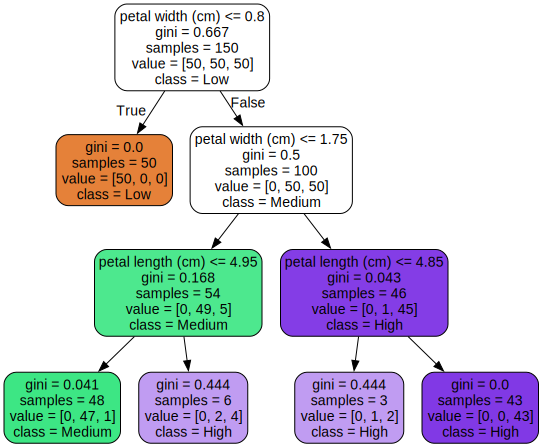

In [24]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz
import os
os.environ["PATH"] += os.pathsep + r"C:\\Program Files\\Graphviz\\bin"

# Assume data1 is your DataFrame
X = data.drop('target', axis=1)
y = data['target']

# 🔥 Convert continuous → categorical
y = pd.cut(y, bins=3, labels=[0, 1, 2])

# Train model
model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

# Visualize
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph

6. Write a Python program to train a Decision Tree Classifier with a maximum depth of 3 and compare its accuracy with a fully grown tree 

In [25]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [26]:
x = data.drop('target', axis=1)
y = data['target']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=1)

In [27]:
tree = DecisionTreeClassifier(max_depth=3,random_state=42)
tree

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
model4 = tree.fit(x_train, y_train)
model4

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
y_pred_tree3 = model4.predict(x_test)
y_pred_tree3

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [30]:
print(accuracy_score(y_test, y_pred_tree3))

0.9736842105263158


In [31]:
tree = DecisionTreeClassifier(random_state=42)
model5 = tree.fit(x_train, y_train)
model5

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
y_pred = model5.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [33]:
print(accuracy_score(y_test, y_pred_tree))

0.9736842105263158


7. Write a Python program to train a Decision Tree Classifier using min_samples_split=5 and compare its accuracy with a default tree 

In [34]:
tree = DecisionTreeClassifier(min_samples_split=5, random_state=42)
tree

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [37]:
x = data.drop('target', axis=1)
y = data['target']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=1)

In [38]:
model6 = tree.fit(x_train, y_train)
model6

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
y_pred_tree4 = model6.predict(x_test)
y_pred_tree4

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

In [41]:
print(accuracy_score(y_test, y_pred_tree4))

0.9666666666666667


In [42]:
tree = DecisionTreeClassifier(random_state=42)
model5 = tree.fit(x_train, y_train)
model5

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_pred = model5.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

In [45]:
print(accuracy_score(y_test, y_pred))

0.9666666666666667


8. Write a Python program to apply feature scaling before training a Decision Tree Classifier and compare its accuracy with unscaled data 

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
data = load_iris()
X = data.data
y = data.target


In [48]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:

# 🌳 Model 1: Without Scaling
model_unscaled = DecisionTreeClassifier(random_state=42)
model_unscaled.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:

y_pred_unscaled = model_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)


In [51]:

# ⚖️ Apply Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [53]:
model_scaled = DecisionTreeClassifier(random_state=42)
model_scaled.fit(X_train_scaled, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:

y_pred_scaled = model_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

# 📊 Compare Results
print("Accuracy without scaling:", acc_unscaled)
print("Accuracy with scaling:", acc_scaled)

Accuracy without scaling: 1.0
Accuracy with scaling: 1.0


9. Write a Python program to train a Decision Tree Classifier using One-vs-Rest (OvR) strategy for multiclass classification 

In [56]:
from sklearn.multiclass import OneVsRestClassifier


# Load dataset (multiclass)
data = load_iris()
X = data.data
y = data.target   # 3 classes: 0, 1, 2

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🌳 Base model
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

# 🔁 Apply One-vs-Rest strategy
ovr_model = OneVsRestClassifier(dt)

# Train model
ovr_model.fit(X_train, y_train)

# Predictions
y_pred = ovr_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy (OvR Decision Tree):", accuracy)

Accuracy (OvR Decision Tree): 1.0


10. Write a Python program to train a Decision Tree Classifier and display the feature importance scores 

In [57]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

# Get feature importances
importance = pd.Series(model.feature_importances_, index=X.columns)

# Display feature importance
print("Feature Importances:\n")
print(importance)

Feature Importances:

sepal length (cm)    0.013333
sepal width (cm)     0.000000
petal length (cm)    0.564056
petal width (cm)     0.422611
dtype: float64


11. Write a Python program to train a Decision Tree Regressor with max_depth=5 and compare its performance with an unrestricted tree 

In [65]:
data1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [66]:
x = data1.iloc[:, :-1]
y = data1.iloc[:, -1]  # Select last column as target variable


In [67]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=1)


In [68]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [69]:
model7 = tree.fit(x_train, y_train)
model7

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [70]:
ypred_tree = model7.predict(x_test)
ypred_tree

array([3.85557412, 0.90285386, 2.21336395, ..., 1.9284035 , 1.9284035 ,
       1.12811126], shape=(4128,))

In [74]:
print(r2_score(y_test, ypred_tree))

0.6134879544159668


In [71]:
tree = DecisionTreeRegressor(random_state=42)
tree

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [75]:
model7 = tree.fit(x_train, y_train)
model7

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [76]:
ypred_tree1 = model7.predict(x_test)
ypred_tree1

array([4.219, 0.669, 2.296, ..., 1.667, 2.726, 0.983], shape=(4128,))

In [77]:
print(r2_score(y_test, ypred_tree1))

0.615863698380156


12. Write a Python program to train a Decision Tree Classifier, apply Cost Complexity Pruning (CCP), and visualize its effect on accuracy 

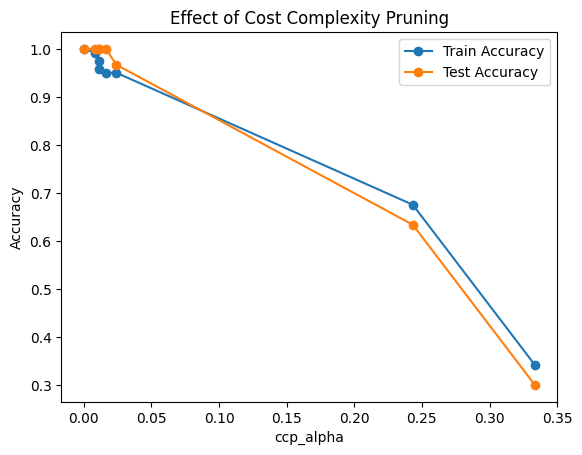

In [78]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 1: Get CCP alphas
model = DecisionTreeClassifier(random_state=42)
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

train_acc = []
test_acc = []

# Step 2: Train models for different alpha values
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

# Step 3: Plot accuracy vs alpha
plt.figure()
plt.plot(ccp_alphas, train_acc, marker='o', label="Train Accuracy")
plt.plot(ccp_alphas, test_acc, marker='o', label="Test Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Effect of Cost Complexity Pruning")
plt.legend()
plt.show()

13. Write a Python program to train a Decision Tree Classifier and evaluate its performance using Precision, Recall, and F1-Score 

In [83]:
data = load_iris()
data = pd.DataFrame(data.data, columns=data.feature_names)
data['target'] = load_iris().target

In [85]:
x = data.drop('target', axis=1)
y = data['target']


In [86]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=1)



In [87]:
tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)
tree

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [88]:
ypred = tree.predict(x_test)
ypred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [89]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



14. Write a Python program to train a Decision Tree Classifier and visualize the confusion matrix using seaborn 

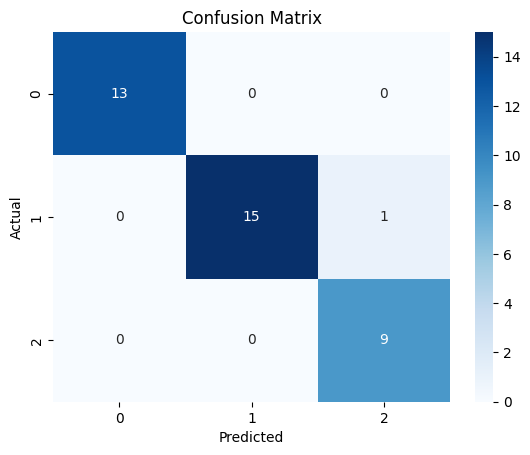

In [91]:
cmf = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cmf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

15. Write a Python program to train a Decision Tree Classifier and use GridSearchCV to find the optimal values for max_depth and min_samples_split.

In [92]:
parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1,2,3,4,5],
    'min_samples_split': [2, 5, 10]}

In [93]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=tree, param_grid=parameters, cv=5,verbose=3)


In [94]:
data 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [95]:
x = data.drop('target', axis=1)
y = data['target']

In [96]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=1) 

In [97]:
m = grid.fit(x_train, y_train)
m

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END criterion=gini, max_depth=1, min_samples_split=2;, score=0.696 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_split=2;, score=0.696 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_split=2;, score=0.682 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_samples_split=2;, score=0.682 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, min_samples_split=2;, score=0.727 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, min_samples_split=5;, score=0.696 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_split=5;, score=0.696 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_split=5;, score=0.682 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_samples_split=5;, score=0.682 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, min_samples_split=5;, score=0.727 total t

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [98]:
ypred2 = m.predict(x_test)
ypred2


array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0])

In [100]:
print(grid.best_estimator_)

DecisionTreeClassifier(max_depth=4)


In [104]:
print(grid.best_score_)

0.9462450592885375


In [105]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}


In [106]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



In [107]:
print(confusion_matrix(y_test, y_pred_tree))

[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]


In [110]:
print(accuracy_score(y_test, ypred2))

0.9736842105263158
